In [38]:
import sys
sys.path.append("..")

In [2]:
from torch.utils.data import DataLoader
from src.dataset import YesNoSpeechCommands, collate_fn


data_root= "../data"
batch_size = 64
num_workers = 0

train_ds = YesNoSpeechCommands(root=data_root, subset="training")
val_ds = YesNoSpeechCommands(root=data_root, subset="validation")
test_ds = YesNoSpeechCommands(root=data_root, subset="testing")

train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        collate_fn=collate_fn,
    )
val_loader = DataLoader(
        val_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        collate_fn=collate_fn,
    )
test_loader = DataLoader(
        test_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        collate_fn=collate_fn,
    )

100%|████████████████████████████████████████████████████████████████████████████████████████| 11005/11005 [00:25<00:00, 438.21it/s]


In [3]:
len(train_ds), len(test_ds), len(val_ds)

(6358, 824, 803)

In [4]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

In [5]:
from src.model import SpeechCommandModel

model = SpeechCommandModel(n_mels=20, groups=1).to(device)

In [6]:
import random
import numpy as np
import torch

SEED = 42

# Python random
random.seed(SEED)

# Numpy
np.random.seed(SEED)

# PyTorch
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

In [7]:
%load_ext autoreload
%autoreload 2
from src.train import train_model

epochs = 20
lr = 0.001

history, best_model, best_epoch, best_val_acc = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        epochs=epochs,
        lr=lr,
        device=device,
    )

Epoch 1/20 | train_loss=0.2469 | val_loss=0.1235 | val_acc=0.9465 | time=3.43s
Epoch 2/20 | train_loss=0.0823 | val_loss=0.0902 | val_acc=0.9738 | time=3.32s
Epoch 3/20 | train_loss=0.0596 | val_loss=0.0702 | val_acc=0.9726 | time=3.20s
Epoch 4/20 | train_loss=0.0483 | val_loss=0.0362 | val_acc=0.9888 | time=3.09s
Epoch 5/20 | train_loss=0.0406 | val_loss=0.0332 | val_acc=0.9863 | time=3.17s
Epoch 6/20 | train_loss=0.0321 | val_loss=0.0264 | val_acc=0.9863 | time=3.05s
Epoch 7/20 | train_loss=0.0315 | val_loss=0.0246 | val_acc=0.9913 | time=3.00s
Epoch 8/20 | train_loss=0.0338 | val_loss=0.1485 | val_acc=0.9552 | time=3.53s
Epoch 9/20 | train_loss=0.0282 | val_loss=0.0282 | val_acc=0.9925 | time=3.14s
Epoch 10/20 | train_loss=0.0270 | val_loss=0.0181 | val_acc=0.9963 | time=3.16s
Epoch 11/20 | train_loss=0.0218 | val_loss=0.0176 | val_acc=0.9925 | time=3.32s
Epoch 12/20 | train_loss=0.0268 | val_loss=0.0220 | val_acc=0.9913 | time=3.25s
Epoch 13/20 | train_loss=0.0216 | val_loss=0.0194

In [8]:
best_epoch

10

In [9]:
from src.train import evaluate
from torch import nn

avg_loss, acc = evaluate(best_model, test_loader, nn.CrossEntropyLoss(), device)
print("Test loss: ", round(avg_loss, 4))
print("Test accuracy: ", round(acc, 4))

Test loss:  0.0096
Test accuracy:  0.9976


In [10]:
%load_ext autoreload
%autoreload 2

from src.experiments import run_mel_experiments

mel_results = run_mel_experiments(
    mel_values=[16, 20, 32, 40, 64, 80],
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    epochs=10,
    lr=1e-3,
    device=device,
    early_stopping_patience=3,
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload

Running experiment with n_mels=16
Epoch 1/10 | train_loss=0.2419 | val_loss=0.1158 | val_acc=0.9502 | time=3.27s
Epoch 2/10 | train_loss=0.0805 | val_loss=0.0469 | val_acc=0.9826 | time=3.04s
Epoch 3/10 | train_loss=0.0565 | val_loss=0.0548 | val_acc=0.9826 | time=3.40s
Epoch 4/10 | train_loss=0.0428 | val_loss=0.0507 | val_acc=0.9851 | time=3.10s
Epoch 5/10 | train_loss=0.0449 | val_loss=0.0521 | val_acc=0.9763 | time=3.04s
Epoch 6/10 | train_loss=0.0457 | val_loss=0.0356 | val_acc=0.9863 | time=2.99s
Epoch 7/10 | train_loss=0.0396 | val_loss=0.0400 | val_acc=0.9851 | time=2.99s
Epoch 8/10 | train_loss=0.0299 | val_loss=0.0259 | val_acc=0.9888 | time=2.98s
Epoch 9/10 | train_loss=0.0284 | val_loss=0.0255 | val_acc=0.9913 | time=2.95s
Epoch 10/10 | train_loss=0.0283 | val_loss=0.0267 | val_acc=0.9900 | time=2.99s
[RESULT] n_mels=16 | best_epoch=9 | best_val_acc=0.9913 | test_acc=0.9927 | params=277

In [11]:
from src.utils import count_flops, count_parameters

count_flops(model)

2356608.0

In [12]:
count_parameters(model)

28354

In [13]:
from src.experiments import run_mel_experiments
help(run_mel_experiments)

Help on function run_mel_experiments in module src.experiments:

run_mel_experiments(mel_values: list[int], train_loader, val_loader, test_loader, epochs: int = 10, lr: float = 0.001, device: str | None = None, early_stopping_patience: int | None = None) -> list[dict[str, typing.Any]]



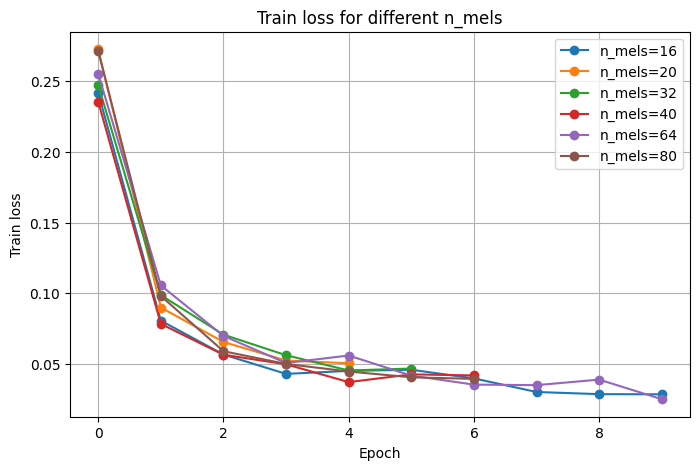

In [14]:
import matplotlib.pyplot as plt
import os
os.makedirs("../reports/figures", exist_ok=True)

plt.figure(figsize=(8, 5))

for res in mel_results:
    plt.plot(
        res["history"]["train_loss"],
        marker="o",
        label=f'n_mels={res["n_mels"]}'
    )

plt.xlabel("Epoch")
plt.ylabel("Train loss")
plt.title("Train loss for different n_mels")
plt.legend()
plt.grid(True)
plt.savefig("../reports/figures/train_loss_n_mels.png", dpi=200, bbox_inches="tight")
plt.show()

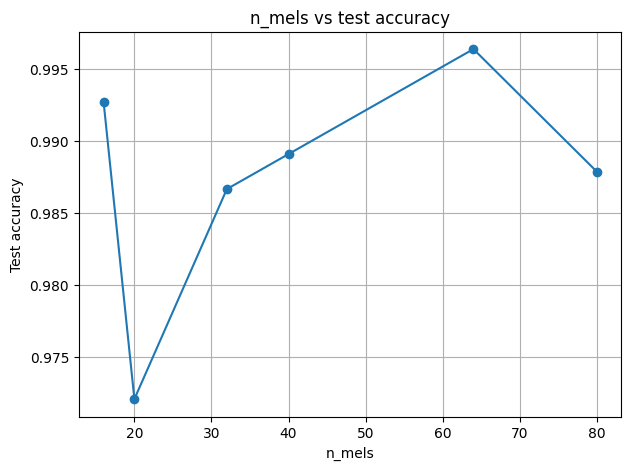

In [15]:
plt.figure(figsize=(7, 5))

plt.plot(
    [res["n_mels"] for res in mel_results],
    [res["test_acc"] for res in mel_results],
    marker="o"
)

plt.xlabel("n_mels")
plt.ylabel("Test accuracy")
plt.title("n_mels vs test accuracy")
plt.grid(True)
plt.savefig("../reports/figures/test_accuracy_n_mels.png", dpi=200, bbox_inches="tight")
plt.show()

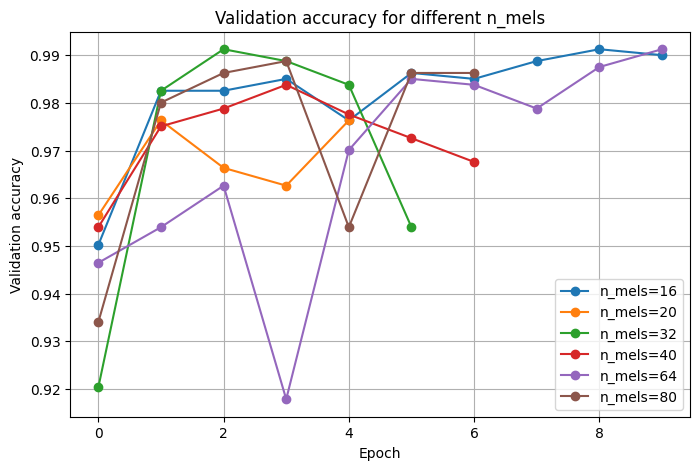

In [16]:
plt.figure(figsize=(8, 5))

for res in mel_results:
    plt.plot(
        res["history"]["val_acc"],
        marker="o",
        label=f'n_mels={res["n_mels"]}'
    )

plt.xlabel("Epoch")
plt.ylabel("Validation accuracy")
plt.title("Validation accuracy for different n_mels")
plt.legend()
plt.grid(True)
plt.savefig("../reports/figures/val_accuracy_n_mels.png", dpi=200, bbox_inches="tight")
plt.show()

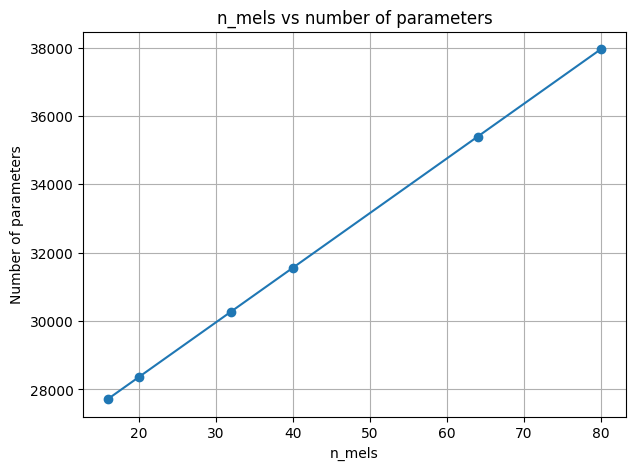

In [17]:
plt.figure(figsize=(7, 5))

plt.plot(
    [res["n_mels"] for res in mel_results],
    [res["num_params"] for res in mel_results],
    marker="o"
)

plt.xlabel("n_mels")
plt.ylabel("Number of parameters")
plt.title("n_mels vs number of parameters")
plt.grid(True)
plt.savefig("../reports/figures/num_params_n_mels.png", dpi=200, bbox_inches="tight")
plt.show()

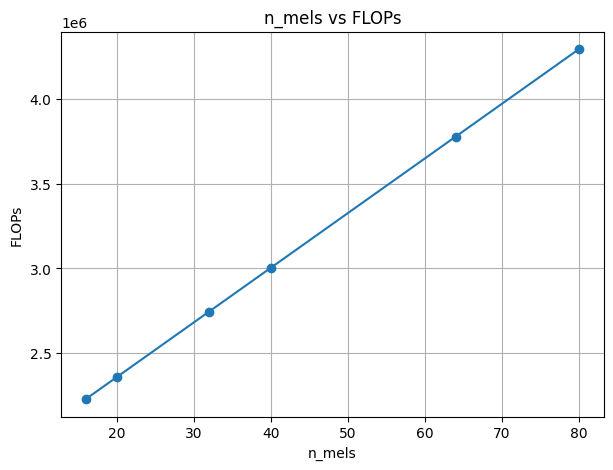

In [18]:
valid_results = [res for res in mel_results if res["flops"] is not None]

plt.figure(figsize=(7, 5))

plt.plot(
    [res["n_mels"] for res in valid_results],
    [res["flops"] for res in valid_results],
    marker="o"
)

plt.xlabel("n_mels")
plt.ylabel("FLOPs")
plt.title("n_mels vs FLOPs")
plt.grid(True)
plt.savefig("../reports/figures/flops_n_mels.png", dpi=200, bbox_inches="tight")
plt.show()

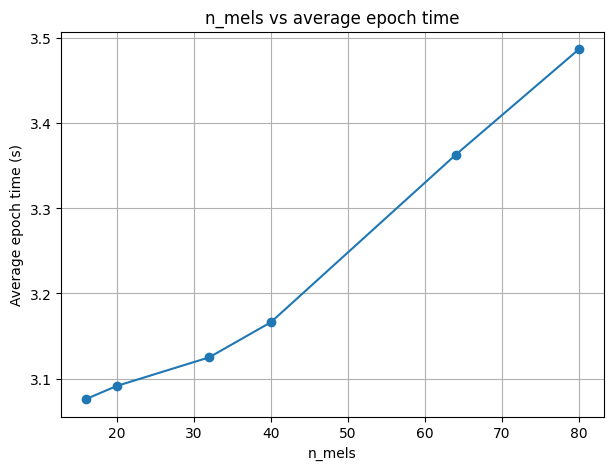

In [19]:
plt.figure(figsize=(7, 5))

plt.plot(
    [res["n_mels"] for res in mel_results],
    [sum(res["history"]["epoch_time"]) / len(res["history"]["epoch_time"]) for res in mel_results],
    marker="o"
)

plt.xlabel("n_mels")
plt.ylabel("Average epoch time (s)")
plt.title("n_mels vs average epoch time")
plt.grid(True)
plt.savefig("../reports/figures/average_epoch_times_n_mels.png", dpi=200, bbox_inches="tight")
plt.show()

In [20]:
for res in mel_results:
    avg_epoch_time = sum(res["history"]["epoch_time"]) / len(res["history"]["epoch_time"])
    print(
        f"n_mels={res['n_mels']}, "
        f"best_epoch={res['best_epoch']}, "
        f"best_val_acc={res['best_val_acc']:.4f}, "
        f"test_acc={res['test_acc']:.4f}, "
        f"params={res['num_params']}, "
        f"flops={res['flops']}, "
        f"avg_epoch_time={avg_epoch_time:.2f}s"
    )

n_mels=16, best_epoch=9, best_val_acc=0.9913, test_acc=0.9927, params=27714, flops=2227328.0, avg_epoch_time=3.08s
n_mels=20, best_epoch=2, best_val_acc=0.9763, test_acc=0.9721, params=28354, flops=2356608.0, avg_epoch_time=3.09s
n_mels=32, best_epoch=3, best_val_acc=0.9913, test_acc=0.9867, params=30274, flops=2744448.0, avg_epoch_time=3.13s
n_mels=40, best_epoch=4, best_val_acc=0.9838, test_acc=0.9891, params=31554, flops=3003008.0, avg_epoch_time=3.17s
n_mels=64, best_epoch=10, best_val_acc=0.9913, test_acc=0.9964, params=35394, flops=3778688.0, avg_epoch_time=3.36s
n_mels=80, best_epoch=4, best_val_acc=0.9888, test_acc=0.9879, params=37954, flops=4295808.0, avg_epoch_time=3.49s


In [21]:
%load_ext autoreload
%autoreload 2


from src.experiments import run_group_experiments

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [24]:
from src.experiments import run_group_experiments

group_results = run_group_experiments(
    group_values=[1, 2, 4, 8, 16, 32],
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    n_mels=32,
    epochs=10,
    lr=1e-3,
    device=device,
    early_stopping_patience=3,
)


Running experiment with groups=1
Epoch 1/10 | train_loss=0.2350 | val_loss=0.0918 | val_acc=0.9589 | time=3.19s
Epoch 2/10 | train_loss=0.0840 | val_loss=0.2076 | val_acc=0.9141 | time=3.09s
Epoch 3/10 | train_loss=0.0722 | val_loss=0.0457 | val_acc=0.9851 | time=3.48s
Epoch 4/10 | train_loss=0.0529 | val_loss=0.0523 | val_acc=0.9838 | time=3.46s
Epoch 5/10 | train_loss=0.0412 | val_loss=0.0290 | val_acc=0.9875 | time=3.39s
Epoch 6/10 | train_loss=0.0435 | val_loss=0.0501 | val_acc=0.9801 | time=4.64s
Epoch 7/10 | train_loss=0.0350 | val_loss=0.0247 | val_acc=0.9913 | time=4.52s
Epoch 8/10 | train_loss=0.0290 | val_loss=0.0358 | val_acc=0.9888 | time=3.44s
Epoch 9/10 | train_loss=0.0276 | val_loss=0.0196 | val_acc=0.9925 | time=3.67s
Epoch 10/10 | train_loss=0.0280 | val_loss=0.0265 | val_acc=0.9913 | time=3.64s
[RESULT] groups=1 | best_epoch=9 | best_val_acc=0.9925 | test_acc=0.9915 | params=30274 | flops=2744448.0

Running experiment with groups=2
Epoch 1/10 | train_loss=0.2957 | va

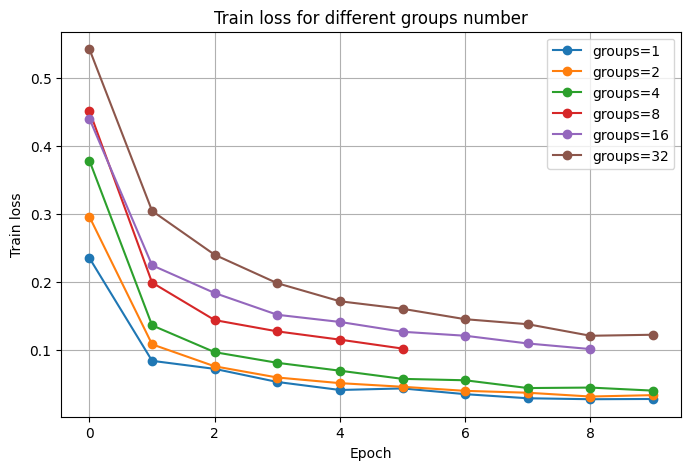

In [26]:
os.makedirs("../reports/figures", exist_ok=True)

plt.figure(figsize=(8, 5))

for res in group_results:
    plt.plot(
        res["history"]["train_loss"],
        marker="o",
        label=f'groups={res["groups"]}'
    )

plt.xlabel("Epoch")
plt.ylabel("Train loss")
plt.title("Train loss for different groups number")
plt.legend()
plt.grid(True)
plt.savefig("../reports/figures/train_loss_groups.png", dpi=200, bbox_inches="tight")
plt.show()

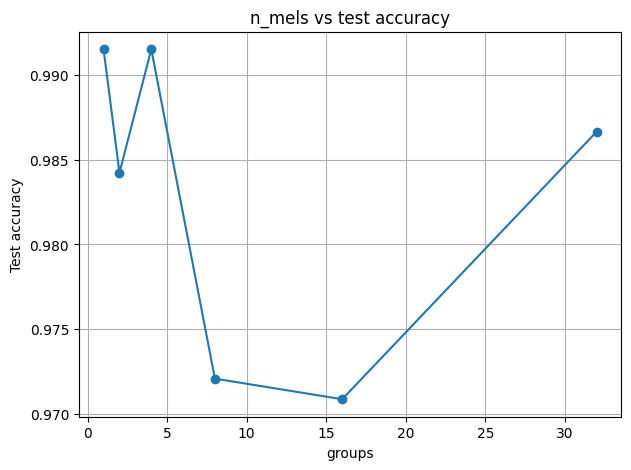

In [33]:
plt.figure(figsize=(7, 5))

plt.plot(
    [res["groups"] for res in group_results],
    [res["test_acc"] for res in group_results],
    marker="o"
)

plt.xlabel("groups")
plt.ylabel("Test accuracy")
plt.title("n_mels vs test accuracy")
plt.grid(True)
plt.savefig("../reports/figures/test_accuracy_groups.png", dpi=200, bbox_inches="tight")
plt.show()

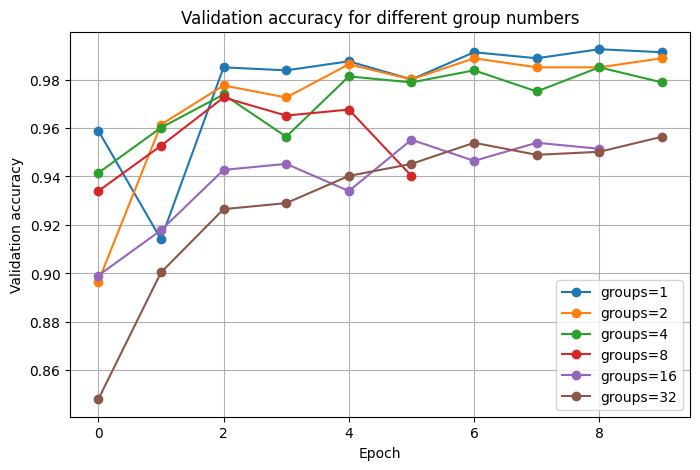

In [29]:
plt.figure(figsize=(8, 5))

for res in group_results:
    plt.plot(
        res["history"]["val_acc"],
        marker="o",
        label=f'groups={res["groups"]}'
    )

plt.xlabel("Epoch")
plt.ylabel("Validation accuracy")
plt.title("Validation accuracy for different group numbers")
plt.legend()
plt.grid(True)
plt.savefig("../reports/figures/val_accuracy_groups.png", dpi=200, bbox_inches="tight")
plt.show()

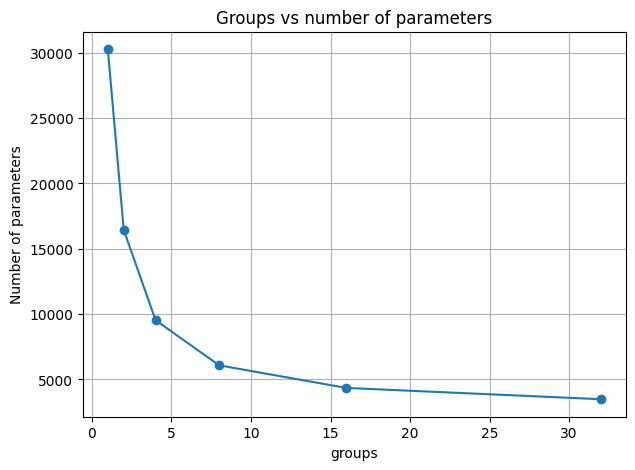

In [31]:
plt.figure(figsize=(7, 5))

plt.plot(
    [res["groups"] for res in group_results],
    [res["num_params"] for res in group_results],
    marker="o"
)

plt.xlabel("groups")
plt.ylabel("Number of parameters")
plt.title("Groups vs number of parameters")
plt.grid(True)
plt.savefig("../reports/figures/num_params_groups.png", dpi=200, bbox_inches="tight")
plt.show()

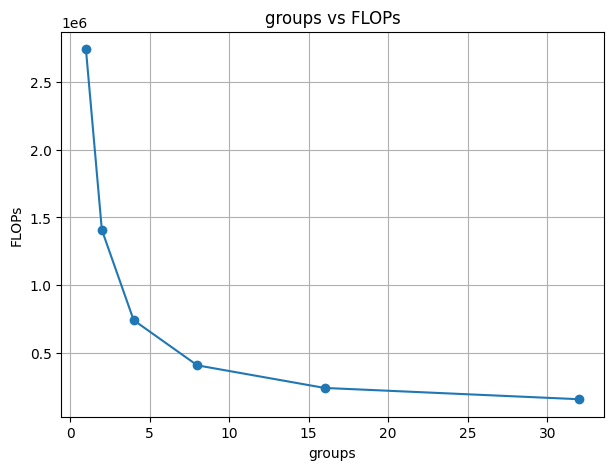

In [32]:
valid_results = [res for res in group_results if res["flops"] is not None]

plt.figure(figsize=(7, 5))

plt.plot(
    [res["groups"] for res in valid_results],
    [res["flops"] for res in valid_results],
    marker="o"
)

plt.xlabel("groups")
plt.ylabel("FLOPs")
plt.title("groups vs FLOPs")
plt.grid(True)
plt.savefig("../reports/figures/flops_groups.png", dpi=200, bbox_inches="tight")
plt.show()

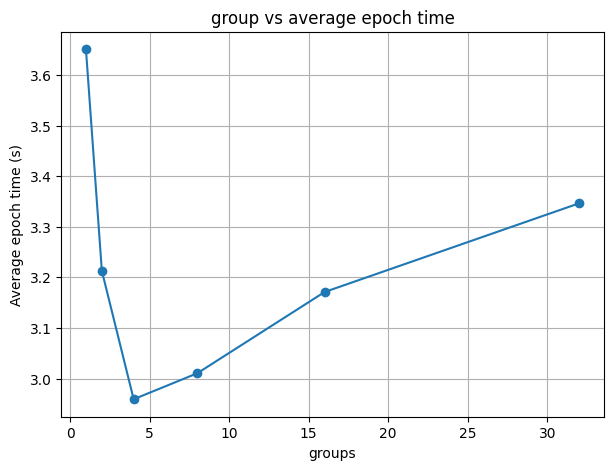

In [36]:
plt.figure(figsize=(7, 5))

plt.plot(
    [res["groups"] for res in group_results],
    [sum(res["history"]["epoch_time"]) / len(res["history"]["epoch_time"]) for res in group_results],
    marker="o"
)

plt.xlabel("groups")
plt.ylabel("Average epoch time (s)")
plt.title("group vs average epoch time")
plt.grid(True)
plt.savefig("../reports/figures/average_epoch_times_groups.png", dpi=200, bbox_inches="tight")
plt.show()

In [37]:
for res in group_results:
    avg_epoch_time = sum(res["history"]["epoch_time"]) / len(res["history"]["epoch_time"])
    print(
        f"groups={res['groups']}, "
        f"best_epoch={res['best_epoch']}, "
        f"best_val_acc={res['best_val_acc']:.4f}, "
        f"test_acc={res['test_acc']:.4f}, "
        f"params={res['num_params']}, "
        f"flops={res['flops']}, "
        f"avg_epoch_time={avg_epoch_time:.2f}s"
    )

groups=1, best_epoch=9, best_val_acc=0.9925, test_acc=0.9915, params=30274, flops=2744448.0, avg_epoch_time=3.65s
groups=2, best_epoch=7, best_val_acc=0.9888, test_acc=0.9842, params=16450, flops=1408128.0, avg_epoch_time=3.21s
groups=4, best_epoch=9, best_val_acc=0.9851, test_acc=0.9915, params=9538, flops=739968.0, avg_epoch_time=2.96s
groups=8, best_epoch=3, best_val_acc=0.9726, test_acc=0.9721, params=6082, flops=405888.0, avg_epoch_time=3.01s
groups=16, best_epoch=6, best_val_acc=0.9552, test_acc=0.9709, params=4354, flops=238848.0, avg_epoch_time=3.17s
groups=32, best_epoch=10, best_val_acc=0.9564, test_acc=0.9867, params=3490, flops=155328.0, avg_epoch_time=3.35s
